In [43]:
from xaikd import approximators, models

from xaikd.approximators import ApproximatorMode

from xaikd.utils import count_params_in_model

from matplotlib import pyplot as plt 

import numpy as np 

from thop import profile

import torch

In [39]:
arr_resnet18_input_dim = {
    "layer3": (1, 128, 16, 16),
    "layer4": (1, 256, 8, 8),
    
}

In [59]:
mac, params = profile(models.get_model("cifar100-resnet18-p1"), inputs=(torch.randn(1, 3, 32, 32), ))
print(f"mac={mac:.2e}     | params={params:.2e}")

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_avgpool() for <class 'torch.nn.modules.pooling.AvgPool2d'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
mac=5.58e+08     | params=1.12e+07


In [61]:
from torchvision.models import resnet

model = resnet.resnet18()
model.eval()

mac, params = profile(model, inputs=(torch.randn(1, 3, 224, 224), ))
print(f"mac={mac:.2e}     | params={params:.2e}")

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_adap_avgpool() for <class 'torch.nn.modules.pooling.AdaptiveAvgPool2d'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
mac=1.82e+09     | params=1.17e+07


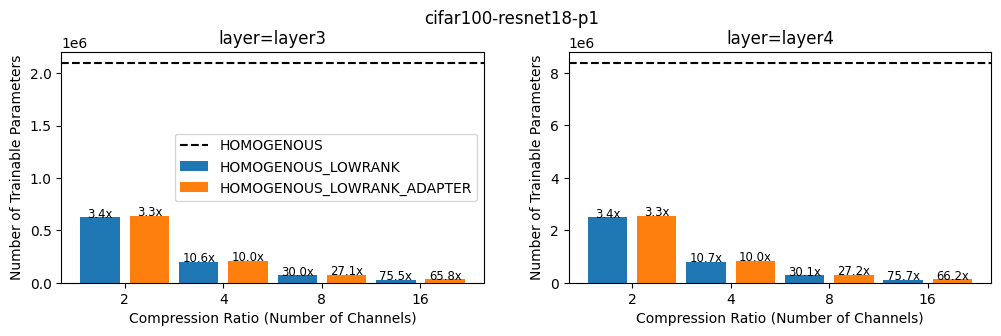

In [55]:
def label(mode):
    return f"{mode}".split(".")[-1]

def viz(model_name, arr_layers, arr_compression_ratio=[2, 4, 8, 16]):
    arr_modes = [
        ApproximatorMode.HOMOGENOUS_LOWRANK,
        ApproximatorMode.HOMOGENOUS_LOWRANK_ADAPTER
    ]
    
    
    model = models.get_model(model_name)
    
    ncols = len(arr_layers)
    
    plt.figure(figsize=(ncols*6, 3))
    plt.suptitle(f"{model_name}", y=1.02)
    


    for lix, layer in enumerate(arr_layers):
        plt.subplot(1, ncols, lix+1)
        plt.title(f"layer={layer}")
        approx_identity = approximators.construct_approximator_for(
            model,
            layer,
            compression_ratio=1.0,
            mode=ApproximatorMode.HOMOGENOUS
        )

        ref_total, ref_trainable = count_params_in_model(approx_identity)

        assert ref_trainable == ref_total
        
        plt.ylabel("Number of Trainable Parameters")

        ticks = np.arange(len(arr_compression_ratio)) * 2
        plt.axhline(
            ref_trainable,
            label=label(ApproximatorMode.HOMOGENOUS),
            color="k",
            ls="--"
        )

        for mix, mode in enumerate(arr_modes):
            stats = []
            for aix, comp_ratio in enumerate(arr_compression_ratio):
                _approx = approximators.construct_approximator_for(
                    model,
                    layer,
                    compression_ratio=comp_ratio,
                    mode=mode
                )

                total, trainable = count_params_in_model(_approx)
                assert total == trainable

                stats.append(trainable)
            
            plt.bar(ticks + mix, stats, label=label(mode))
            
            for six, total_param in enumerate(stats):
                plt.text(
                    ticks[six]+mix, total_param, f"{ref_total/total_param:.1f}x",
                    ha="center",
                    fontsize="small"
                )
        plt.xticks(ticks + 0.5, arr_compression_ratio)
        
        plt.xlabel("Compression Ratio (Number of Channels)")
        if lix == 0:
            plt.legend()

viz(
    "cifar100-resnet18-p1",
    ["layer3", "layer4"]
)

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_convNd() for

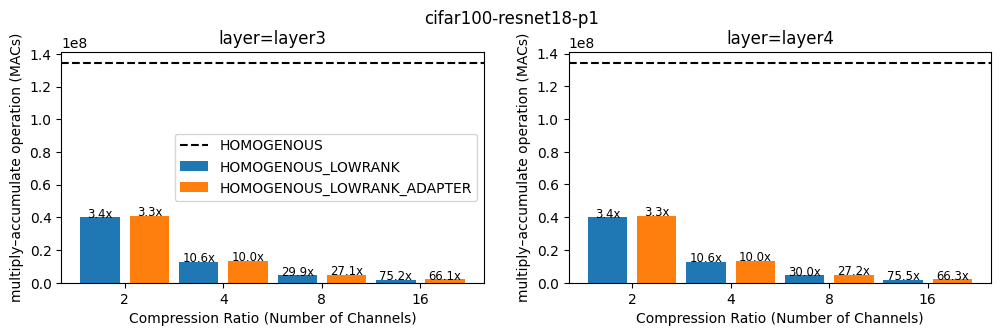

In [56]:
def viz_macs(model_name, arr_layers, arr_compression_ratio=[2, 4, 8, 16]):
    arr_modes = [
        ApproximatorMode.HOMOGENOUS_LOWRANK,
        ApproximatorMode.HOMOGENOUS_LOWRANK_ADAPTER
    ]
    
    
    model = models.get_model(model_name)
    
    ncols = len(arr_layers)
    
    plt.figure(figsize=(ncols*6, 3))
    plt.suptitle(f"{model_name}", y=1.02)
    
    

    for lix, layer in enumerate(arr_layers):
        
        layer_inp_dim = arr_resnet18_input_dim[layer]
        layer_inp = torch.randn(*layer_inp_dim)
        plt.subplot(1, ncols, lix+1)
        plt.title(f"layer={layer}")
        approx_identity = approximators.construct_approximator_for(
            model,
            layer,
            compression_ratio=1.0,
            mode=ApproximatorMode.HOMOGENOUS
        )

        ref_total, _ = profile(approx_identity, inputs=(layer_inp, ))

        plt.ylabel("multiply–accumulate operation (MACs)")

        ticks = np.arange(len(arr_compression_ratio)) * 2
        plt.axhline(
            ref_total,
            label=label(ApproximatorMode.HOMOGENOUS),
            color="k",
            ls="--"
        )

        for mix, mode in enumerate(arr_modes):
            stats = []
            for aix, comp_ratio in enumerate(arr_compression_ratio):
                _approx = approximators.construct_approximator_for(
                    model,
                    layer,
                    compression_ratio=comp_ratio,
                    mode=mode
                )

                
                stat, _ = profile(_approx, inputs=(layer_inp, ))
                stats.append(stat)
            
            plt.bar(ticks + mix, stats, label=label(mode))
            
            for six, total_param in enumerate(stats):
                plt.text(
                    ticks[six]+mix, total_param, f"{ref_total/total_param:.1f}x",
                    ha="center",
                    fontsize="small"
                )
        plt.xticks(ticks + 0.5, arr_compression_ratio)
        
        plt.xlabel("Compression Ratio (Number of Channels)")
        if lix == 0:
            plt.legend()

viz_macs(
    "cifar100-resnet18-p1",
    ["layer3", "layer4"]
)

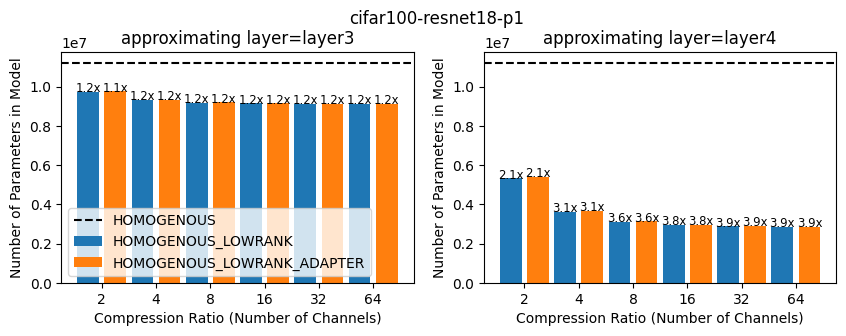

In [34]:
def replace_model_at_layer(model_name, layer, approx):
    model = models.get_model(model_name)
    setattr(model, layer, approx)
    return model

def viz_for_whole_model(model_name, arr_layers, arr_compression_ratio=[2, 4, 8, 16, 32, 64]):
    arr_modes = [
        ApproximatorMode.HOMOGENOUS_LOWRANK,
        ApproximatorMode.HOMOGENOUS_LOWRANK_ADAPTER
    ]
    
    
    model = models.get_model(model_name)
    
    ncols = len(arr_layers)
    
    plt.figure(figsize=(ncols*5, 3))
    plt.suptitle(f"{model_name}", y=1.02)

    for lix, layer in enumerate(arr_layers):
        plt.subplot(1, ncols, lix+1)
        plt.title(f"approximating layer={layer}")
        approx_identity = approximators.construct_approximator_for(
            model,
            layer,
            compression_ratio=1.0,
            mode=ApproximatorMode.HOMOGENOUS
        )

        ref_total, ref_trainable = count_params_in_model(
            replace_model_at_layer(model_name, layer, approx_identity)
        )
        
        assert ref_total == ref_trainable



        plt.ylabel("Number of Parameters in Model")

        ticks = np.arange(len(arr_compression_ratio)) * 2
        plt.axhline(
            ref_trainable,
            label=label(ApproximatorMode.HOMOGENOUS),
            color="k",
            ls="--"
        )

        for mix, mode in enumerate(arr_modes):
            stats = []
            for aix, comp_ratio in enumerate(arr_compression_ratio):
                _approx = approximators.construct_approximator_for(
                    model,
                    layer,
                    compression_ratio=comp_ratio,
                    mode=mode
                )

                total, trainable = count_params_in_model(
                    replace_model_at_layer(model_name, layer, _approx)
                )
                assert total == trainable

                stats.append(trainable)
            
            plt.bar(ticks + mix, stats, label=label(mode))
            
            for six, total_param in enumerate(stats):
                plt.text(
                    ticks[six]+mix, total_param, f"{ref_total/total_param:.1f}x",
                    ha="center",
                    fontsize="small"
                )
        plt.xticks(ticks + 0.5, arr_compression_ratio)
        
        plt.xlabel("Compression Ratio (Number of Channels)")
        if lix == 0:
            plt.legend()
viz_for_whole_model(
    "cifar100-resnet18-p1",
    ["layer3", "layer4"]
)

In [31]:
512 / (64)

8.0

In [35]:
approximators.compute_compressed_dimension(512, 64)

8